# Disneyland Wait Time Modeling (XGBoost, Random Forest)
## Rachel Wantuch
### Scraping a website for my data

In [1]:
# packages needed to pull data from an API
import requests
import time
from datetime import date, timedelta
#!pip install --upgrade numexpr
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

## Loading the Data (Jan 2025-July 2025)

In [2]:
df_apr= pd.read_csv("download_starwarsriseoftheresistance_apr_55073_2026_08_10_11_57_04.csv")
df_feb=pd.read_csv("download_starwarsriseoftheresistance_feb_55073_2026_08_10_11_55_57.csv")
df_jan=pd.read_csv("download_starwarsriseoftheresistance_jan_55073_2026_08_10_11_54_31.csv")
df_jul=pd.read_csv("download_starwarsriseoftheresistance_jul_55073_2026_08_10_11_57_17.csv")
df_jun=pd.read_csv("download_starwarsriseoftheresistance_jun_55073_2026_08_10_11_57_14.csv")
df_mar=pd.read_csv("download_starwarsriseoftheresistance_mar_55073_2026_08_10_11_56_59.csv")
df_may=pd.read_csv("download_starwarsriseoftheresistance_may_55073_2026_08_10_11_57_09.csv")

# Combine these into one big dataset.
Since all the columns are the same I am going to use concat().

In [3]:
df=pd.concat([df_jan,df_feb,df_mar,df_apr,df_may,df_jun,df_jul], ignore_index=True)
pd.reset_option('display.max_rows')

In [4]:
df.head()

,Ride,Date/Time,Wait Time
0,Star Wars: Rise of the Resistance,2025-01-01 08:03:02,35
1,Star Wars: Rise of the Resistance,2025-01-01 08:04:03,35
2,Star Wars: Rise of the Resistance,2025-01-01 08:05:03,35
3,Star Wars: Rise of the Resistance,2025-01-01 08:06:02,35
4,Star Wars: Rise of the Resistance,2025-01-01 08:07:03,35


In [5]:
df.dtypes

Ride           str
Date/Time      str
Wait Time    int64
dtype: object

In [6]:
df['Date/Time']=pd.to_datetime(df['Date/Time'])
df_5min=df.groupby(pd.Grouper(key='Date/Time', freq='5min'))['Wait Time'].mean().reset_index()
df_5min.head()

,Date/Time,Wait Time
0,2025-01-01 08:00:00,35.0
1,2025-01-01 08:05:00,35.0
2,2025-01-01 08:10:00,45.0
3,2025-01-01 08:15:00,75.0
4,2025-01-01 08:20:00,75.0


In [7]:
df.shape

(291665, 3)

In [8]:
#df_5min.set_index('Date/Time', inplace=True)
#df_hourly=df_5min['Wait Time'].resample('h').mean()

df_hourly=df_5min.groupby(pd.Grouper(key='Date/Time', freq='h'))['Wait Time'].mean().reset_index()
df_hourly.head()

,Date/Time,Wait Time
0,2025-01-01 08:00:00,69.583333
1,2025-01-01 09:00:00,83.166667
2,2025-01-01 10:00:00,87.916667
3,2025-01-01 11:00:00,85.166667
4,2025-01-01 12:00:00,90.833333


In [9]:
#average hourly wait times using 6 months of data
avg_hourly=df_hourly['Wait Time'].mean()
print(avg_hourly)

55.7258416683399


In [10]:
#converting the Date column to date time format
df_hourly['Date/Time']=pd.to_datetime(df_hourly['Date/Time'])
#Detecting the day of the week using the .dt.day_name method and adding it to a new column
df_hourly['Day']=df_hourly['Date/Time'].dt.day_name()
#df_hourly['Date']=df_hourly['Date/Time'].dt.date
#Using hour instead of time so itts easier for the XGBRegressor to use
df_hourly['Time']=df_hourly['Date/Time'].dt.hour
#If I want a numeric month column
df_hourly['Month_Numeric']=df_hourly['Date/Time'].dt.month
#If I want a month name column
df_hourly['Month_Name']=df_hourly['Date/Time'].dt.month_name()
df_hourly['Day_Numeric']=df_hourly['Date/Time'].dt.day
df_hourly['Year']=df_hourly['Date/Time'].dt.year

In [11]:
df_hourly.head()

,Date/Time,Wait Time,Day,Time,Month_Numeric,Month_Name,Day_Numeric,Year
0,2025-01-01 08:00:00,69.583333,Wednesday,8,1,January,1,2025
1,2025-01-01 09:00:00,83.166667,Wednesday,9,1,January,1,2025
2,2025-01-01 10:00:00,87.916667,Wednesday,10,1,January,1,2025
3,2025-01-01 11:00:00,85.166667,Wednesday,11,1,January,1,2025
4,2025-01-01 12:00:00,90.833333,Wednesday,12,1,January,1,2025


In [12]:
df_hourly.shape

(13839, 8)

In [13]:
df_hourly[df_hourly['Wait Time'].isna()]

,Date/Time,Wait Time,Day,Time,Month_Numeric,Month_Name,Day_Numeric,Year
15,2025-01-01 23:00:00,NaN,Wednesday,23,1,January,1,2025
16,2025-01-02 00:00:00,NaN,Thursday,0,1,January,2,2025
17,2025-01-02 01:00:00,NaN,Thursday,1,1,January,2,2025
18,2025-01-02 02:00:00,NaN,Thursday,2,1,January,2,2025
19,2025-01-02 03:00:00,NaN,Thursday,3,1,January,2,2025
...,...,...,...,...,...,...,...,...
13819,2026-07-31 03:00:00,NaN,Friday,3,7,July,31,2026
13820,2026-07-31 04:00:00,NaN,Friday,4,7,July,31,2026
13821,2026-07-31 05:00:00,NaN,Friday,5,7,July,31,2026
13822,2026-07-31 06:00:00,NaN,Friday,6,7,July,31,2026


In [14]:
df_hourly=df_hourly.dropna(subset=['Wait Time'])
df_hourly.shape

(5699, 8)

In [15]:
df_hourly['Wait Time']=df_hourly['Wait Time'].round(2)

## Adding weather markers to the hourly dataset using Python's Meteostat
Meteostat is a Python package that gets its historical weather data from NOAA

In [16]:
!pip install meteostat
#!pip install --upgrade meteostat

In [17]:
import meteostat as ms
from datetime import datetime

In [18]:
location=ms.Point(33.8353, -117.9145)
start=datetime(2025, 1, 1, 8, 0)
end=datetime(2025, 8, 1, 0, 0)
stations=ms.stations.nearby(location, limit=1)

In [19]:
data=ms.hourly(stations, start, end)
df_weather=data.fetch()
print(df_weather)

                             temp  rhum  prcp  snwd  wdir  wspd  wpgt    pres  \
station time                                                                    
KFUL0   2025-01-01 08:00:00  11.1    48   0.0  <NA>   280   7.6  <NA>  1018.2   
        2025-01-01 09:00:00  10.6    48   0.0  <NA>     0   0.0  <NA>  1018.0   
        2025-01-01 10:00:00  10.0    48   0.0  <NA>    10   5.4  <NA>  1018.1   
        2025-01-01 11:00:00  10.0    46   0.0  <NA>     0   0.0  <NA>  1018.2   
        2025-01-01 12:00:00   9.4    46   0.0  <NA>     0   0.0  <NA>  1018.1   
...                           ...   ...   ...   ...   ...   ...   ...     ...   
        2025-07-31 20:00:00  26.7    51   0.0  <NA>   208   5.4  <NA>  1015.2   
        2025-07-31 21:00:00  27.2    51   0.0  <NA>   190   9.4  <NA>  1014.9   
        2025-07-31 22:00:00  27.2    51   0.0  <NA>   190  14.8  <NA>  1014.4   
        2025-07-31 23:00:00  26.1    54   0.0  <NA>   200  14.8  <NA>  1014.1   
        2025-08-01 00:00:00 

In [20]:
df_weather.columns.tolist()

['temp',
 'rhum',
 'prcp',
 'snwd',
 'wdir',
 'wspd',
 'wpgt',
 'pres',
 'tsun',
 'cldc',
 'coco']

In [21]:
#Since I only pulled one weather station I can make this only indexed by time and drop the station designation all together.
df_weather=df_weather.reset_index(level='station')
df_weather.head()

,station,temp,rhum,prcp,snwd,wdir,wspd,wpgt,pres,tsun,cldc,coco
time,,,,,,,,,,,,
2025-01-01 08:00:00,KFUL0,11.1,48,0.0,<NA>,280,7.6,<NA>,1018.2,<NA>,3,5
2025-01-01 09:00:00,KFUL0,10.6,48,0.0,<NA>,0,0.0,<NA>,1018.0,<NA>,6,5
2025-01-01 10:00:00,KFUL0,10.0,48,0.0,<NA>,10,5.4,<NA>,1018.1,<NA>,8,5
2025-01-01 11:00:00,KFUL0,10.0,46,0.0,<NA>,0,0.0,<NA>,1018.2,<NA>,3,5
2025-01-01 12:00:00,KFUL0,9.4,46,0.0,<NA>,0,0.0,<NA>,1018.1,<NA>,2,5


In [22]:
#drop station ID
df_weather=df_weather.drop(columns=["station"])

#Moving the "time" column to be a regular column instead of an index column to merge datasets simpler.
df_weather=df_weather.reset_index(names='Date/Time')

## Joining two datasets together on the 'Date/Time' and 'time' column

In [23]:
df_merged=pd.merge(df_hourly, df_weather, on='Date/Time', how='inner')
df_merged.head()

,Date/Time,Wait Time,Day,Time,Month_Numeric,Month_Name,Day_Numeric,Year,temp,rhum,prcp,snwd,wdir,wspd,wpgt,pres,tsun,cldc,coco
0,2025-01-01 08:00:00,69.58,Wednesday,8,1,January,1,2025,11.1,48,0.0,<NA>,280,7.6,<NA>,1018.2,<NA>,3,5
1,2025-01-01 09:00:00,83.17,Wednesday,9,1,January,1,2025,10.6,48,0.0,<NA>,0,0.0,<NA>,1018.0,<NA>,6,5
2,2025-01-01 10:00:00,87.92,Wednesday,10,1,January,1,2025,10.0,48,0.0,<NA>,10,5.4,<NA>,1018.1,<NA>,8,5
3,2025-01-01 11:00:00,85.17,Wednesday,11,1,January,1,2025,10.0,46,0.0,<NA>,0,0.0,<NA>,1018.2,<NA>,3,5
4,2025-01-01 12:00:00,90.83,Wednesday,12,1,January,1,2025,9.4,46,0.0,<NA>,0,0.0,<NA>,1018.1,<NA>,2,5


The dataset is almost ready to work with! Next I will be checking for NA values to see if there is something I can do to address those.

In [24]:
df_merged.isna().sum()

Date/Time           0
Wait Time           0
Day                 0
Time                0
Month_Numeric       0
Month_Name          0
Day_Numeric         0
Year                0
temp               22
rhum               22
prcp               48
snwd             3042
wdir               28
wspd               24
wpgt             2975
pres               16
tsun             3042
cldc               26
coco               90
dtype: int64

In [25]:
df_merged.shape

(3042, 19)

air temperature (temp), dew point (dwpt), relative humidity (rhum), total precipitation (prcp), snowfall and depth (snow, snwd), wind direction/speed/gusts (wdir, wspd, wpgt), sea-level air pressure (pres), sunshine duration (tsun), and weather condition codes (coco)

THe reason we went from 290,000 rows at the beginning is because we aggregated wait times by hour and then dropped values where 'Wait Time' had a NaN value. A brief review showed those hours to be the early morning (think 10pm-8am generally) when the park wasn't open.

Based off the number of rows and some common sense we can get rid of the snow depth column since it never snows except for once in a rare blue moon every few decades. We can also get rid of sunshine duration as it looks like the instrument to read it may have been broken. It's sunny a lot of the time in Southern California. There's no way it wouldn't have had values if it was working.

In [26]:
df_merged[df_merged['wpgt'].isna()]

,Date/Time,Wait Time,Day,Time,Month_Numeric,Month_Name,Day_Numeric,Year,temp,rhum,prcp,snwd,wdir,wspd,wpgt,pres,tsun,cldc,coco
0,2025-01-01 08:00:00,69.58,Wednesday,8,1,January,1,2025,11.1,48,0.0,<NA>,280,7.6,<NA>,1018.2,<NA>,3,5
1,2025-01-01 09:00:00,83.17,Wednesday,9,1,January,1,2025,10.6,48,0.0,<NA>,0,0.0,<NA>,1018.0,<NA>,6,5
2,2025-01-01 10:00:00,87.92,Wednesday,10,1,January,1,2025,10.0,48,0.0,<NA>,10,5.4,<NA>,1018.1,<NA>,8,5
3,2025-01-01 11:00:00,85.17,Wednesday,11,1,January,1,2025,10.0,46,0.0,<NA>,0,0.0,<NA>,1018.2,<NA>,3,5
4,2025-01-01 12:00:00,90.83,Wednesday,12,1,January,1,2025,9.4,46,0.0,<NA>,0,0.0,<NA>,1018.1,<NA>,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3037,2025-07-31 18:00:00,47.33,Thursday,18,7,July,31,2025,22.8,64,0.0,<NA>,0,0.0,<NA>,1015.9,<NA>,0,1
3038,2025-07-31 19:00:00,55.00,Thursday,19,7,July,31,2025,25.0,58,0.0,<NA>,0,0.0,<NA>,1015.4,<NA>,0,1
3039,2025-07-31 20:00:00,43.55,Thursday,20,7,July,31,2025,26.7,51,0.0,<NA>,208,5.4,<NA>,1015.2,<NA>,0,1
3040,2025-07-31 21:00:00,44.20,Thursday,21,7,July,31,2025,27.2,51,0.0,<NA>,190,9.4,<NA>,1014.9,<NA>,0,1


In [27]:
df_merged=df_merged.drop(columns=['snwd', 'tsun', 'wpgt'])
df_merged.isna().sum()

Date/Time         0
Wait Time         0
Day               0
Time              0
Month_Numeric     0
Month_Name        0
Day_Numeric       0
Year              0
temp             22
rhum             22
prcp             48
wdir             28
wspd             24
pres             16
cldc             26
coco             90
dtype: int64

The NaN vales are for the most part sporadic with one exception noted in March where the weather station was reading nothing most days.As a result I am going to drop the rows with NaN values.

In [28]:
pd.set_option('display.max_rows', 10)
df_merged=df_merged.dropna()

### One last thing. We need to transform some of the categorical variables into dummy variables for our model.

In [29]:
#df_merged=pd.get_dummies(df_merged, columns=['Day','Month_Name'], drop_first=True, dtype=int)

# Exploratory Data Analysis
### Is there a day of the week that is better to ride than others?

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
#First I need the average wait time grouped by day of the week
avg_wait=df_merged.groupby('Day')['Wait Time'].mean()

days_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

avg_wait=avg_wait.reindex(days_order)

In [32]:
avg_wait.head()

Day
Monday       54.296860
Tuesday      61.155675
Wednesday    56.080024
Thursday     53.462595
Friday       54.543726
Name: Wait Time, dtype: float64

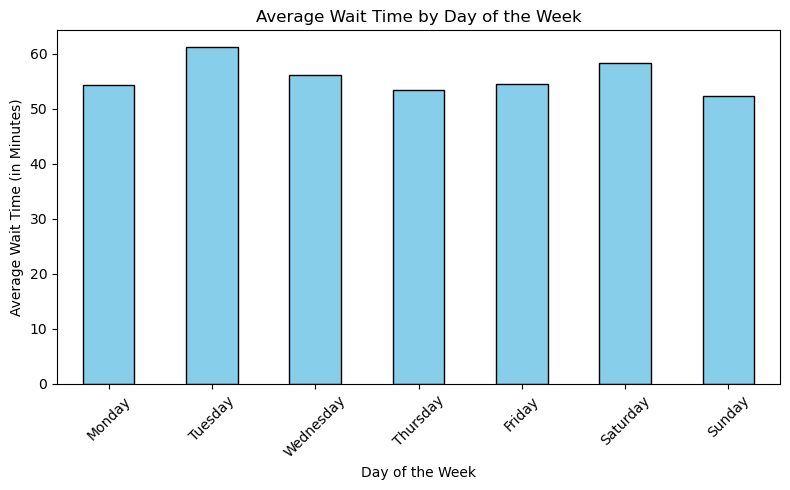

In [33]:
plt.figure(figsize=(8, 5))
avg_wait.plot(kind='bar', color= 'skyblue', edgecolor="black")
plt.xlabel('Day of the Week')
plt.ylabel('Average Wait Time (in Minutes)')
plt.title('Average Wait Time by Day of the Week')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Wait Times Seasonality Trends (if any)

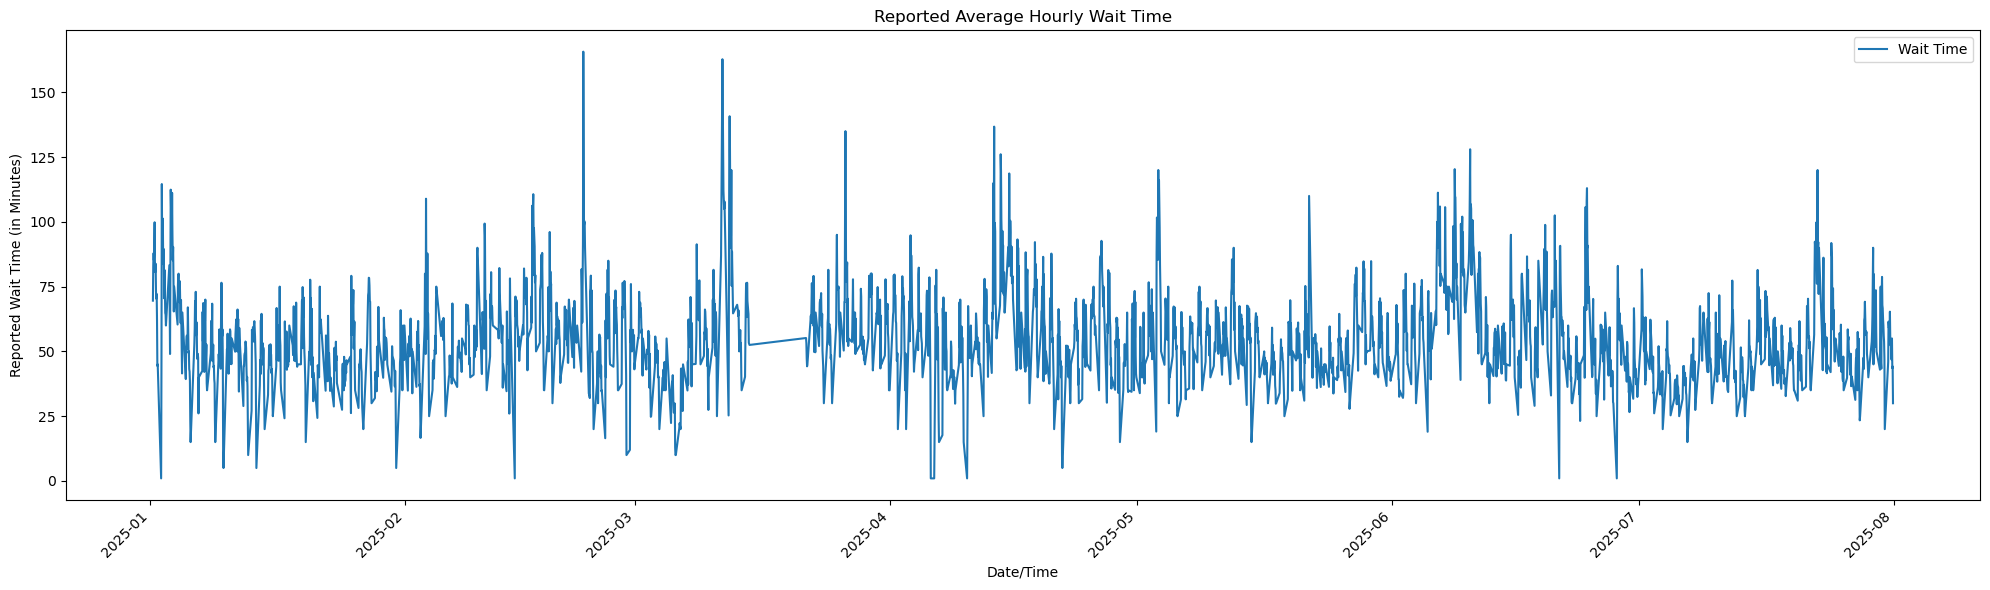

In [34]:
df_merged.plot(x='Date/Time', y='Wait Time', figsize=(20,6))
plt.xlabel('Date/Time')
plt.ylabel('Reported Wait Time (in Minutes)')
plt.title('Reported Average Hourly Wait Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Temeprature Overlaid onto the Wait Times
I did this to show wait times in a clean chart first.

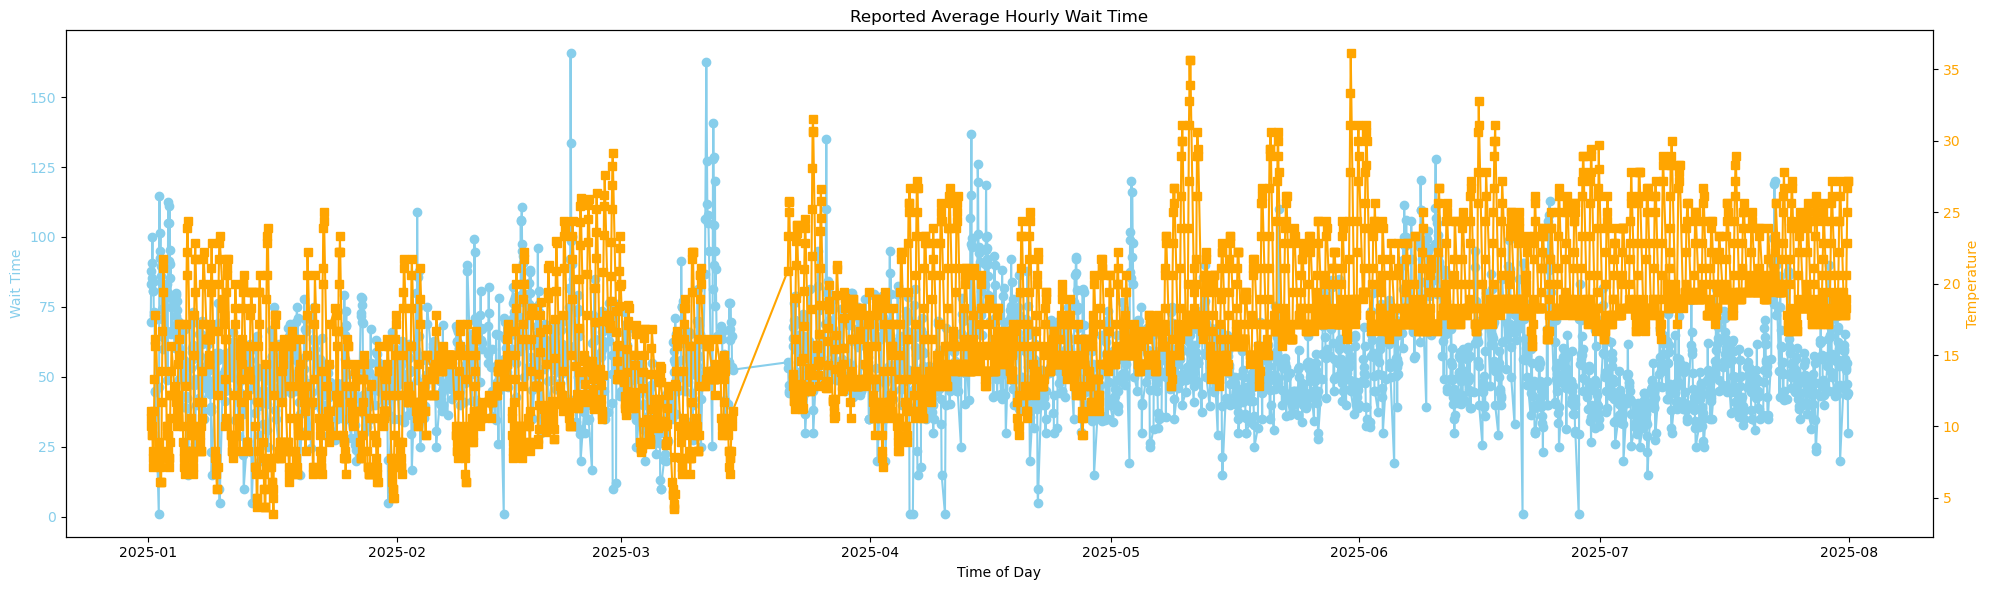

In [35]:
fig, ax1= plt.subplots(figsize=(20,6))

ax1.set_xlabel("Time of Day")
ax1.set_ylabel("Wait Time", color="skyblue")
ax1.plot(df_merged["Date/Time"], df_merged["Wait Time"], color="skyblue", marker="o", label="Wait Time")
ax1.tick_params(axis="y", labelcolor="skyblue")


ax2=ax1.twinx()
ax2.set_ylabel("Temperature", color="orange")
ax2.plot(df_merged["Date/Time"], df_merged["temp"], color="orange", marker="s", label="Temperature")
ax2.tick_params(axis="y", labelcolor="orange")

plt.title('Reported Average Hourly Wait Time')
plt.tight_layout()
plt.show()

## Sarimax

In [36]:
#!pip install --upgrade statsmodels pandas pandas-datareader

In [37]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

In [38]:
#creating a subset dataframe where it is just date and wait time
df_sarimax=df_merged.iloc[:,:2]
df_sarimax.set_index('Date/Time', inplace=True)

result = adfuller(df_sarimax)
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -6.372390772946514
p-value: 2.3277965866087258e-08


This is a very small p-value indicating that the wait time data is not stationary. This should work well with the SARIMA models.

In [39]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import MSTL
import numpy as np
from sklearn.metrics import mean_squared_error

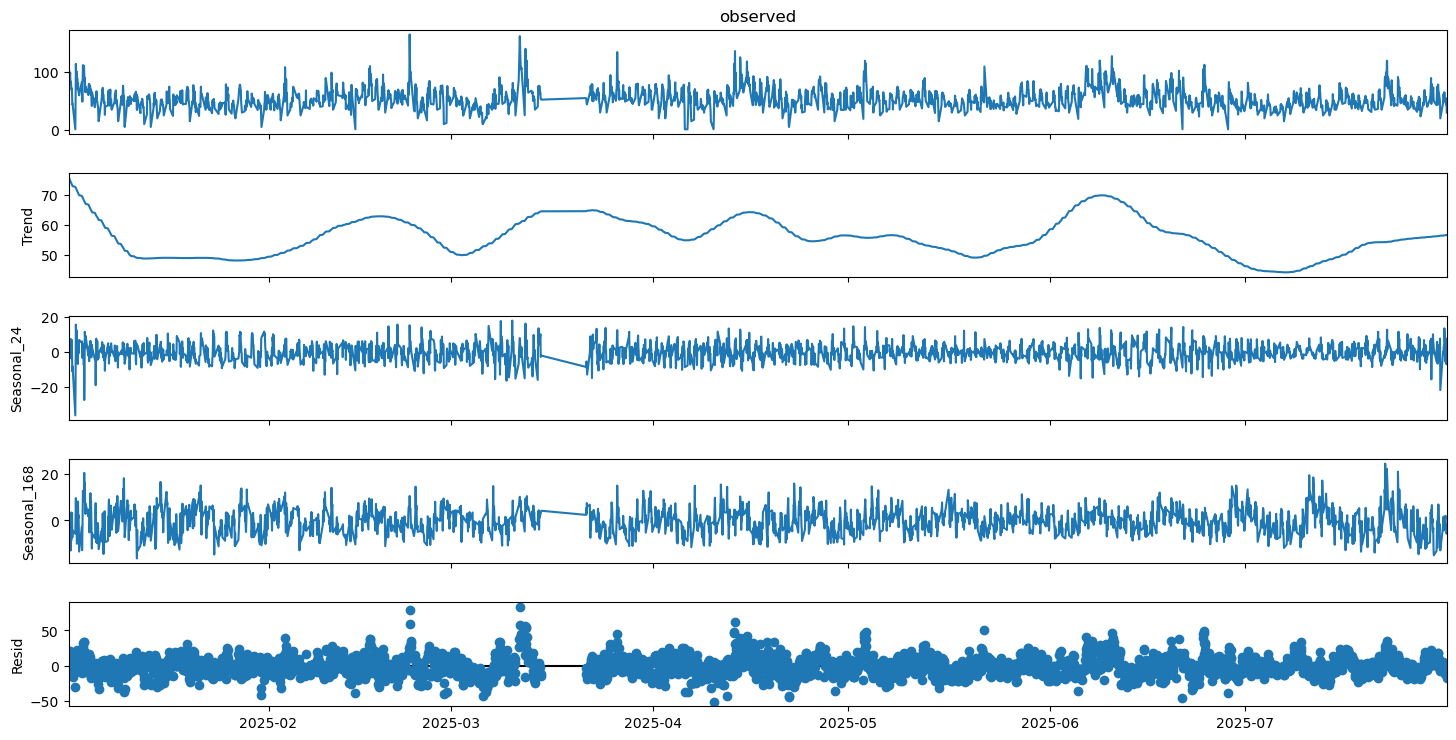

In [40]:
# putting period=24 accounts for a daily cycle while periods= 168 accounts for weekly cycles and the graph will show both
result=MSTL(df_sarimax, periods=(24,168)).fit()

fig=result.plot()
fig.set_size_inches(16,8)
plt.show()

# SARIMAX model
Training Data= First 6 months
Test Data= Last month of data

In [41]:
split_date=pd.to_datetime('2025-07-01')
train_data=df_sarimax[df_sarimax.index < split_date]
test_data=df_sarimax[df_sarimax.index >= split_date]

sarimax_model=SARIMAX(train_data['Wait Time'], order=(1,0,1), seasonal_order=(1, 0, 1, 24))
sarimax_result=sarimax_model.fit()
sarimax_predict=sarimax_result.predict(start=len(train_data), end=len(df_sarimax)-1)
print(sarimax_result.summary())

C:\Users\rwant\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\rwant\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\rwant\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


                                     SARIMAX Results                                      
Dep. Variable:                          Wait Time   No. Observations:                 2452
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 24)   Log Likelihood               -9788.089
Date:                            Sat, 22 Aug 2026   AIC                          19586.178
Time:                                    14:27:33   BIC                          19615.201
Sample:                                         0   HQIC                         19596.725
                                           - 2452                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8390      0.013     67.020      0.000       0.814       0.863
ma.L1         -0.2374      0.020   

In [42]:
rmse= np.sqrt(mean_squared_error(test_data, sarimax_predict))
print(f"RMSE: {rmse:.3f}")

RMSE: 15.562


As an evaluation metric this, to me, is pretty acceptable. Maybe a little closer to a 5 min variance would be better but 15 minutes would fall in my threshold of acceptable.

# XGBoost Model

In [43]:
!pip install xgboost scikit-learn pandas

In [44]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBRegressor

In [45]:
#dropping Year since all the data is in the same Year. A scenario I would keep this column is if I had data spanning multiple years.
df_merged=df_merged.drop(columns=['Year'])

#or making "Date/Time" the index may be better
df_merged.set_index('Date/Time', inplace=True)

df_merged=pd.get_dummies(df_merged, columns=['Day','Month_Name'], drop_first=True, dtype=int)

#create lags
df_merged['lag_1']=df_merged['Wait Time'].shift(1)

#target variable is the y variable
X=df_merged.drop(columns=['Wait Time'])
y=df_merged['Wait Time']

#Split into train and test sets
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

model=XGBRegressor(n_estimators=40, learning_rate=0.1, objective='reg:squarederror', max_depth=3)
model.fit(X_train, y_train)

y_pred=model.predict(X_test)

print(f"XGBRegressor score: {model.score(X_test, y_test):.4f}")

rmse=np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Squared Error: {rmse:.2f}")

XGBRegressor score: 0.5777
Root Mean Squared Error: 11.08


This is better than using SARIMAX for wait time predictions by about 4 minutes. I would still like to hone in the model to get closer to 5 minutes though.When running other lags the RMSE did not improve so this proves that its best to look at just the previous hour to predict wait times.

When compared to the average hourly wait time of 56 minutes this RMSE is alright. I would equate it to a B if it were a grade. Now if you look at wait time by time of day at any given point in those past 6 months the RMSE is greate during busy periods like spring break when we saw a few days with 3 hour waits. It's the opposite story though if we use it for wait times at 8:05am though because the line hasn't even had a chance to form yet.

Changing the estimators from 100 to 50 did improve the RMSE slightly.

Now when looking at the .score() result thats where I lose a little confidence. That basically says that my model explains 57% of the variance in my wait time variable. I guess when you think about all the things that could influence wait time its good but I would like a higher score there. Closer to 80% would make me happy. My guess is downtimes (ride breakdowns) explains a lot of the rest of the variance as well as ticket type breakdown. Disneyland has a lot of annual passholders compared to other Disney Properties. Their threshold for wait times is a lot lower and influenced by the ability to come back the next day, next week, for a few hours, etc.

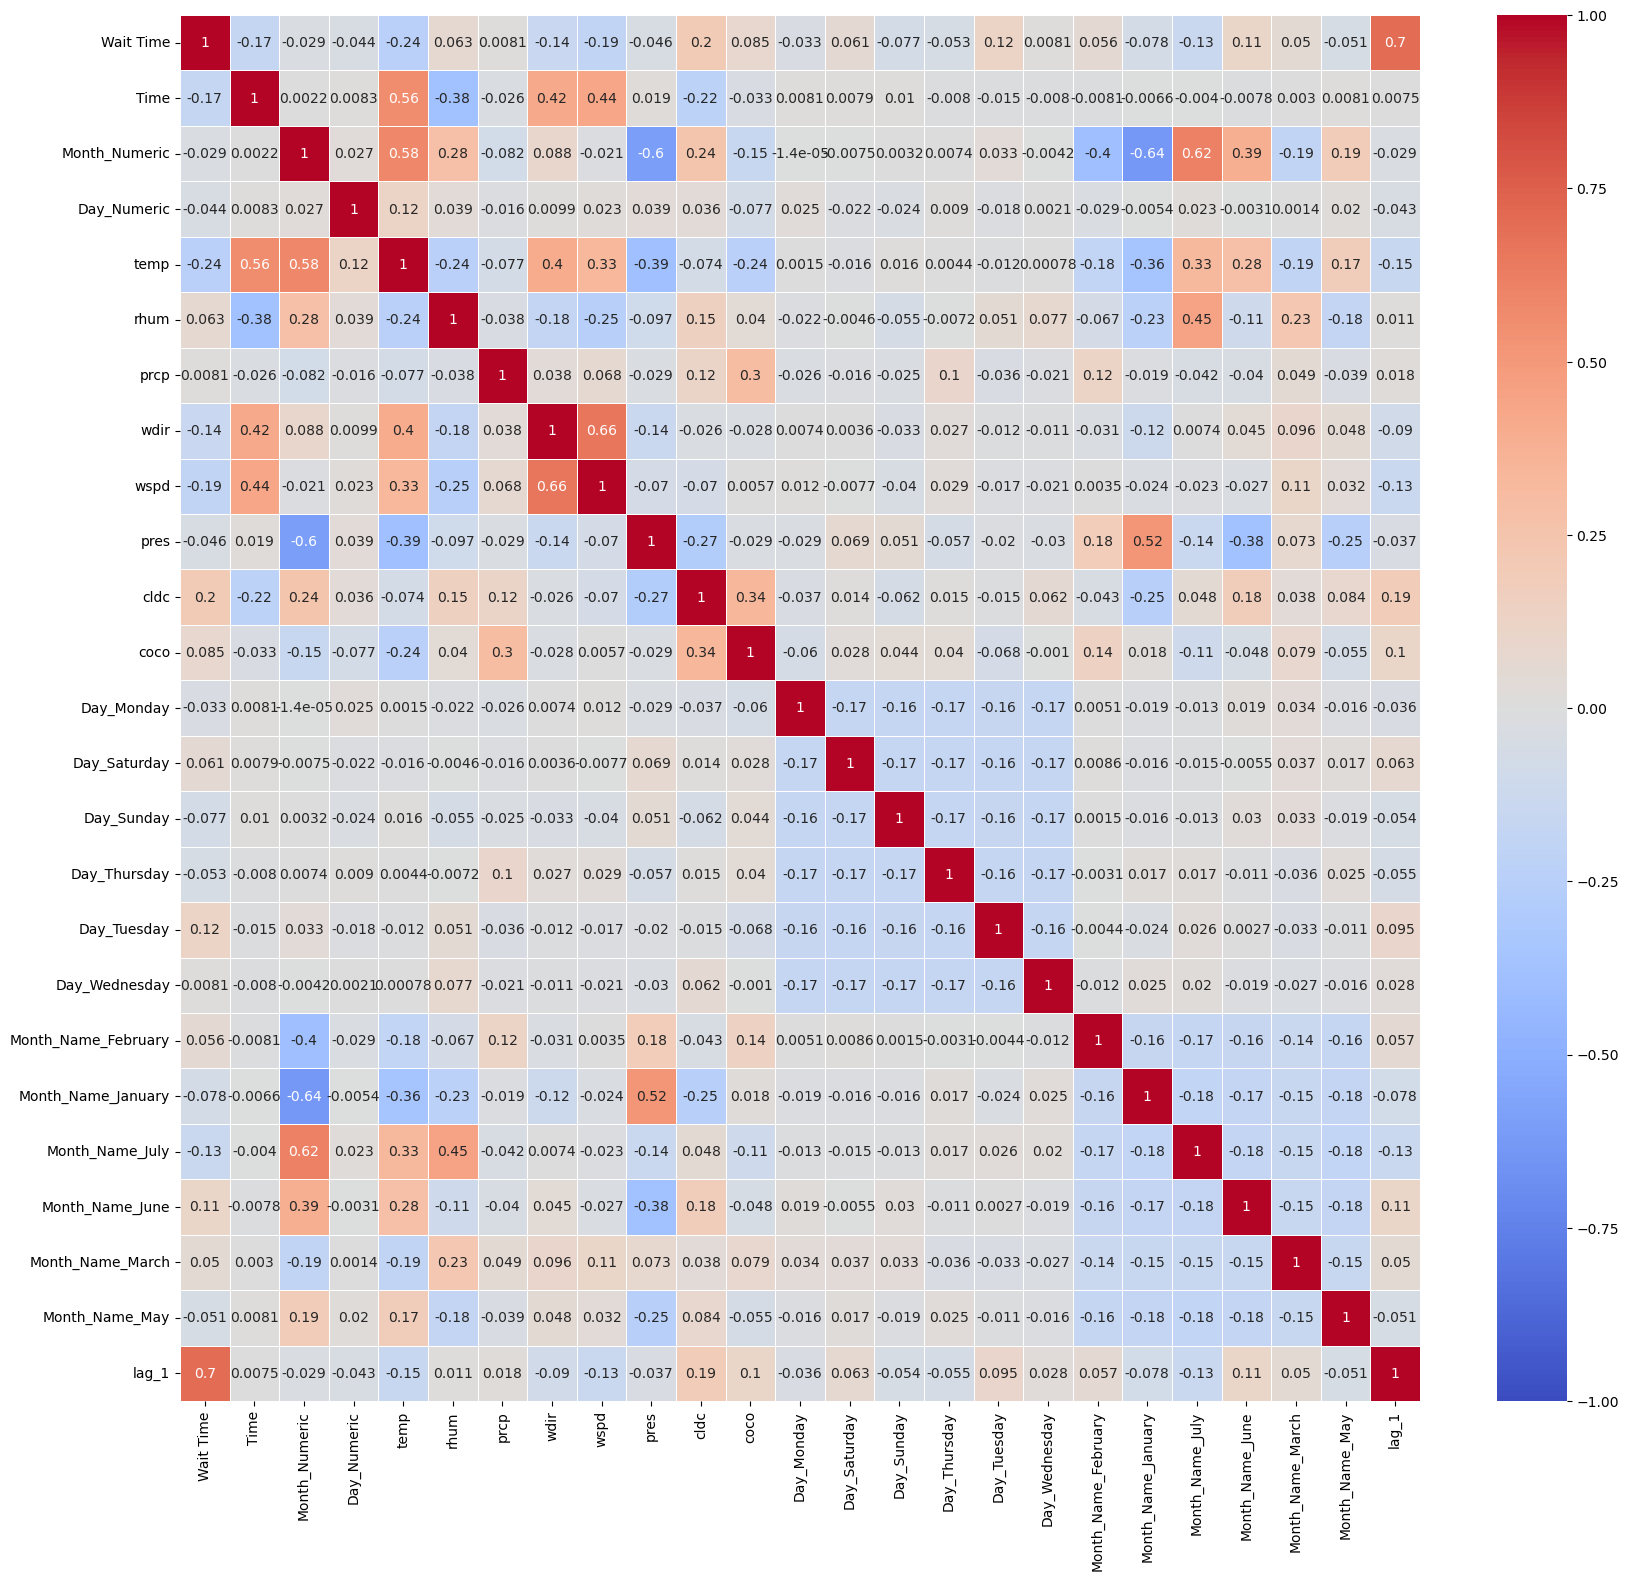

In [54]:
corr_matrix=df_merged.corr()
plt.figure(figsize=(20,18))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidth=0.5
)
plt.show()